---
title: "Equilibriums and Stability"
date: "2026-04-19"
date-modified: last-modified
format:
  html:
    toc: true
---


# Equilibriums and Stability

## 1\. What is an Equilibrium Point?

Consider a general first-order [difference equations](intro-to-difference-equations.ipynb) $x(n+1) = f(x(n))$.

An **equilibrium point** (or fixed point) $x^*$ is a specific value such that if the system reaches $x^*$, it stays there forever. Mathematically, it is defined as:
$$x^* = f(x^*)$$

::: {.callout-important}

## Why are Equilibriums Important?

In many real-world systems, the exact explicit formula for $x(n)$ might be impossible to find. Equilibriums allow us to answer the most important question without solving the equation: *What is the long-term, asymptotic behavior of this system?* Will the population stabilize, explode, or collapse?
:::

## 2\. Stability of an Equilibrium

Just finding an equilibrium isn't enough; we need to know if it is **stable** or **unstable**.

  * If a system is slightly perturbed away from a stable equilibrium, it will naturally return to it over time.
  * If perturbed away from an unstable equilibrium, it will diverge and move further away.

**Elaydi's Stability Criterion:**
Let $x^*$ be an equilibrium point of $x(n+1) = f(x(n))$, where $f$ is continuously differentiable.

  * If $|f'(x^*)| < 1$, then $x^*$ is **asymptotically stable** (an attractor).
  * If $|f'(x^*)| > 1$, then $x^*$ is **unstable** (a repeller).

## 3\. Eventual Equilibrium: Discrete vs. Continuous

One of the most fascinating distinctions raised in Chapter 1 of Elaydi's book is the concept of **eventual equilibrium**.

In discrete-time difference equations, a system can reach an equilibrium point in *finite time* and stay there forever.
$$x(0) \to x(1) \to x(2) \dots \to x(m) = x^*$$

::: {.callout-note}

## The Differential Contrast

In continuous-time **differential equations** (ODE: $x'(t) = f(x)$), reaching an equilibrium in finite time is generally **impossible** (assuming $f$ is reasonably smooth/Lipschitz). Because of the Picard-Lindelöf Uniqueness Theorem, trajectories cannot intersect. An ODE trajectory will approach an equilibrium asymptotically as $t \to \infty$, but will never actually touch it.

Discrete steps $x(n+1)$ do not have "trajectories" to cross; they simply teleport from value to value. Therefore, they can land perfectly on an equilibrium point in finite time\!
:::

## 4\. Visualizing with Cobweb Diagrams

A cobweb diagram is a visual method to predict long-term behavior without doing any algebra.

1.  Draw the curve $y = f(x)$.
2.  Draw the diagonal line $y = x$. (Intersections of these two lines are your equilibriums $x^*$).
3.  Start at $x_0$ on the x-axis. Move vertically to the curve $y=f(x)$.
4.  Move horizontally to the line $y=x$. This sets your new output as your next input.
5.  Repeat.

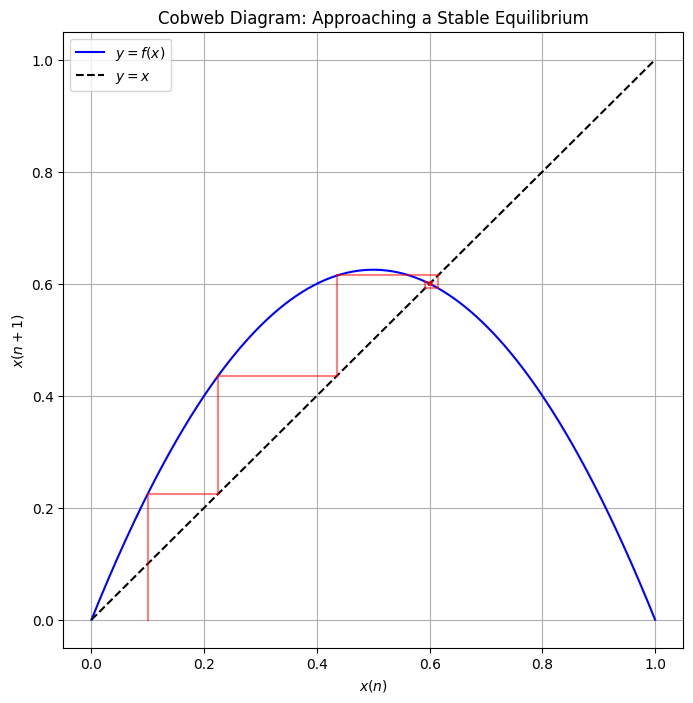

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def cobweb_plot(f, x0, n_iter=20, bounds=(0, 1)):
    t = np.linspace(bounds[0], bounds[1], 400)
    
    plt.figure(figsize=(8, 8))
    plt.plot(t, f(t), 'b', label='$y = f(x)$')
    plt.plot(t, t, 'k--', label='$y = x$')
    
    x, y = x0, f(x0)
    plt.plot([x, x], [0, y], 'r', alpha=0.5)
    
    for _ in range(n_iter):
        # Horizontal to y=x
        plt.plot([x, y], [y, y], 'r', alpha=0.5)
        # Vertical to y=f(x)
        plt.plot([y, y], [y, f(y)], 'r', alpha=0.5)
        x, y = y, f(y)
        
    plt.title("Cobweb Diagram: Approaching a Stable Equilibrium")
    plt.xlabel('$x(n)$')
    plt.ylabel('$x(n+1)$')
    plt.legend()
    plt.grid()
    plt.show()

# Example: Logistic map x(n+1) = r*x(n)*(1-x(n)) for r=2.5
cobweb_plot(lambda x: 2.5 * x * (1 - x), x0=0.1, bounds=(0, 1))